In [1]:
"""
Agent Specialization Analysis

Goals:
1. Compare individual agent performance across all 9 diseases
2. Identify which agent is best for each disease
3. Clinical interpretation of specialization patterns
4. Feature importance from fusion coordinator
5. Visualizations for thesis
"""

import sys
sys.path.append('../../')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# Communication protocol
from src.communication.protocol import DISEASE_LIST

# Plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✅ Imports complete")
print(f"\nAnalyzing {len(DISEASE_LIST)} diseases:")
for i, d in enumerate(DISEASE_LIST, 1):
    print(f"  {i}. {d}")

✅ Imports complete

Analyzing 9 diseases:
  1. SEPSIS
  2. PNEUMONIA
  3. RESPIRATORY_FAILURE
  4. ACUTE_KIDNEY_INJURY
  5. HEART_FAILURE
  6. ATRIAL_FIBRILLATION
  7. CORONARY_ARTERY_DISEASE
  8. ANEMIA
  9. PANCREATITIS


In [2]:
print("="*70)
print("📊 LOADING INDIVIDUAL AGENT PREDICTIONS")
print("="*70)

# Load fusion matrix to extract agent predictions
X_fusion = np.load('../../data/processed/X_fusion_val.npy')
print(f"\n✅ Loaded fusion matrix: {X_fusion.shape}")

# Extract individual agent predictions
agent1_predictions = X_fusion[:, 0:9]    # Agent 1 (Labs)
agent2_predictions = X_fusion[:, 9:18]   # Agent 2 (Notes)
agent3_predictions = X_fusion[:, 18:27]  # Agent 3 (Vitals)

print(f"\nAgent predictions extracted:")
print(f"  Agent 1 (Labs):   {agent1_predictions.shape}")
print(f"  Agent 2 (Notes):  {agent2_predictions.shape}")
print(f"  Agent 3 (Vitals): {agent3_predictions.shape}")

# Load true labels for each disease
y_true = {}
for disease in DISEASE_LIST:
    disease_filename = disease.lower()
    y_true[disease] = np.load(f'../../data/processed/y_fusion_val_{disease_filename}.npy')

print(f"\n✅ Loaded labels for {len(DISEASE_LIST)} diseases")
print(f"   Total samples: {len(y_true[DISEASE_LIST[0]])}")

📊 LOADING INDIVIDUAL AGENT PREDICTIONS

✅ Loaded fusion matrix: (4643, 33)

Agent predictions extracted:
  Agent 1 (Labs):   (4643, 9)
  Agent 2 (Notes):  (4643, 9)
  Agent 3 (Vitals): (4643, 9)

✅ Loaded labels for 9 diseases
   Total samples: 4643


In [3]:
print("\n" + "="*70)
print("📈 CALCULATING AGENT PERFORMANCE METRICS")
print("="*70)

results = []

for i, disease in enumerate(DISEASE_LIST):
    y = y_true[disease]
    
    # Agent 1 predictions (Labs)
    agent1_pred = agent1_predictions[:, i]
    agent1_auc = roc_auc_score(y, agent1_pred)
    
    # Agent 2 predictions (Notes)
    agent2_pred = agent2_predictions[:, i]
    agent2_auc = roc_auc_score(y, agent2_pred)
    
    # Agent 3 predictions (Vitals)
    agent3_pred = agent3_predictions[:, i]
    agent3_auc = roc_auc_score(y, agent3_pred)
    
    # Determine best agent
    aucs = {'Agent 1': agent1_auc, 'Agent 2': agent2_auc, 'Agent 3': agent3_auc}
    best_agent = max(aucs, key=aucs.get)
    best_auc = aucs[best_agent]
    
    # Calculate performance gap
    second_best = sorted(aucs.values())[-2]
    gap = best_auc - second_best
    
    results.append({
        'Disease': disease,
        'Agent 1 (Labs)': agent1_auc,
        'Agent 2 (Notes)': agent2_auc,
        'Agent 3 (Vitals)': agent3_auc,
        'Best Agent': best_agent,
        'Best AUC': best_auc,
        'Gap': gap
    })
    
    print(f"\n{disease}:")
    print(f"  Agent 1 (Labs):   {agent1_auc:.3f}")
    print(f"  Agent 2 (Notes):  {agent2_auc:.3f}")
    print(f"  Agent 3 (Vitals): {agent3_auc:.3f}")
    print(f"  → Best: {best_agent} ({best_auc:.3f})")

# Create DataFrame
results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("📊 SPECIALIZATION SUMMARY")
print("="*70)
print(results_df.to_string(index=False))

# Save results
results_df.to_csv('../../results/agent_specialization_analysis.csv', index=False)
print(f"\n✅ Saved: ../results/agent_specialization_analysis.csv")


📈 CALCULATING AGENT PERFORMANCE METRICS

SEPSIS:
  Agent 1 (Labs):   0.875
  Agent 2 (Notes):  0.757
  Agent 3 (Vitals): 0.828
  → Best: Agent 1 (0.875)

PNEUMONIA:
  Agent 1 (Labs):   0.799
  Agent 2 (Notes):  0.725
  Agent 3 (Vitals): 0.825
  → Best: Agent 3 (0.825)

RESPIRATORY_FAILURE:
  Agent 1 (Labs):   0.851
  Agent 2 (Notes):  0.728
  Agent 3 (Vitals): 0.828
  → Best: Agent 1 (0.851)

ACUTE_KIDNEY_INJURY:
  Agent 1 (Labs):   0.942
  Agent 2 (Notes):  0.744
  Agent 3 (Vitals): 0.842
  → Best: Agent 1 (0.942)

HEART_FAILURE:
  Agent 1 (Labs):   0.819
  Agent 2 (Notes):  0.802
  Agent 3 (Vitals): 0.843
  → Best: Agent 3 (0.843)

ATRIAL_FIBRILLATION:
  Agent 1 (Labs):   0.798
  Agent 2 (Notes):  0.823
  Agent 3 (Vitals): 0.757
  → Best: Agent 2 (0.823)

CORONARY_ARTERY_DISEASE:
  Agent 1 (Labs):   0.844
  Agent 2 (Notes):  0.873
  Agent 3 (Vitals): 0.687
  → Best: Agent 2 (0.873)

ANEMIA:
  Agent 1 (Labs):   0.781
  Agent 2 (Notes):  0.655
  Agent 3 (Vitals): 0.726
  → Best: Agent


📊 Creating Agent Specialization Heatmap...


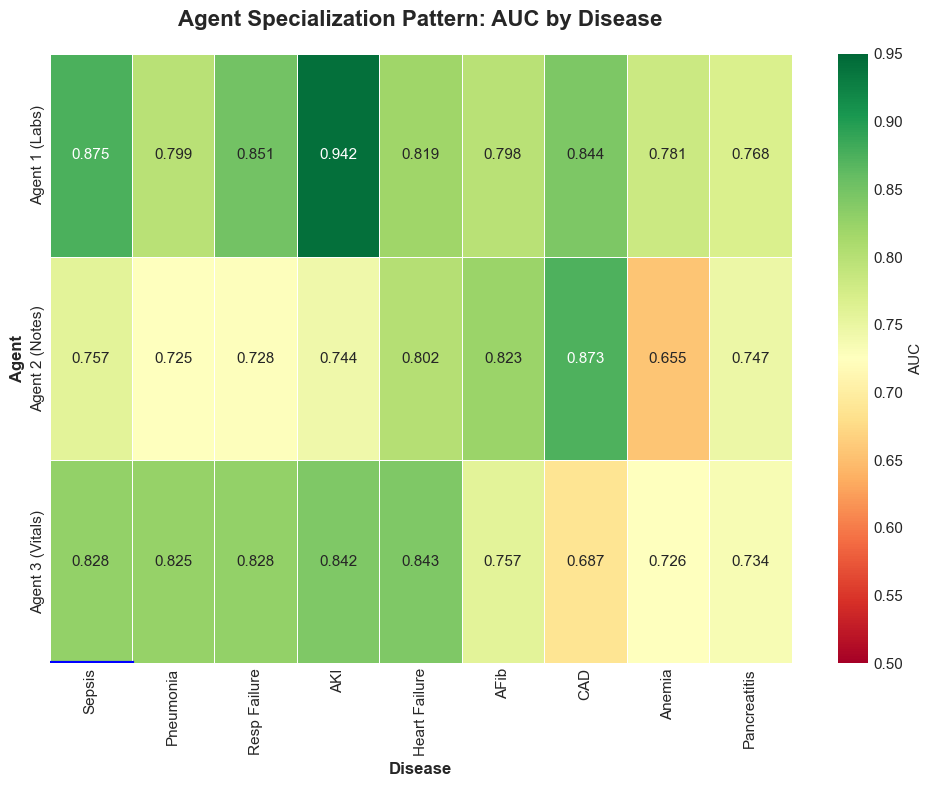

✅ Saved: ../results/agent_specialization_heatmap.png


In [4]:
print("\n📊 Creating Agent Specialization Heatmap...")

# Prepare data for heatmap
heatmap_data = results_df[['Disease', 'Agent 1 (Labs)', 'Agent 2 (Notes)', 'Agent 3 (Vitals)']].copy()
heatmap_data.set_index('Disease', inplace=True)

# Shorten disease names for better display
disease_labels = [
    'Sepsis', 'Pneumonia', 'Resp Failure', 
    'AKI', 'Heart Failure', 'AFib',
    'CAD', 'Anemia', 'Pancreatitis'
]
heatmap_data.index = disease_labels

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    heatmap_data.T,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0.5,
    vmax=0.95,
    cbar_kws={'label': 'AUC'},
    linewidths=0.5,
    ax=ax
)

ax.set_title('Agent Specialization Pattern: AUC by Disease', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Disease', fontsize=12, fontweight='bold')
ax.set_ylabel('Agent', fontsize=12, fontweight='bold')

# Highlight best performer for each disease
for i, col in enumerate(heatmap_data.columns):
    best_idx = heatmap_data[col].argmax()
    ax.add_patch(plt.Rectangle((i, best_idx), 1, 1, 
                               fill=False, edgecolor='blue', lw=3))

plt.tight_layout()
plt.savefig('../../results/agent_specialization_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: ../results/agent_specialization_heatmap.png")


📊 Creating Agent Performance Comparison Bar Chart...


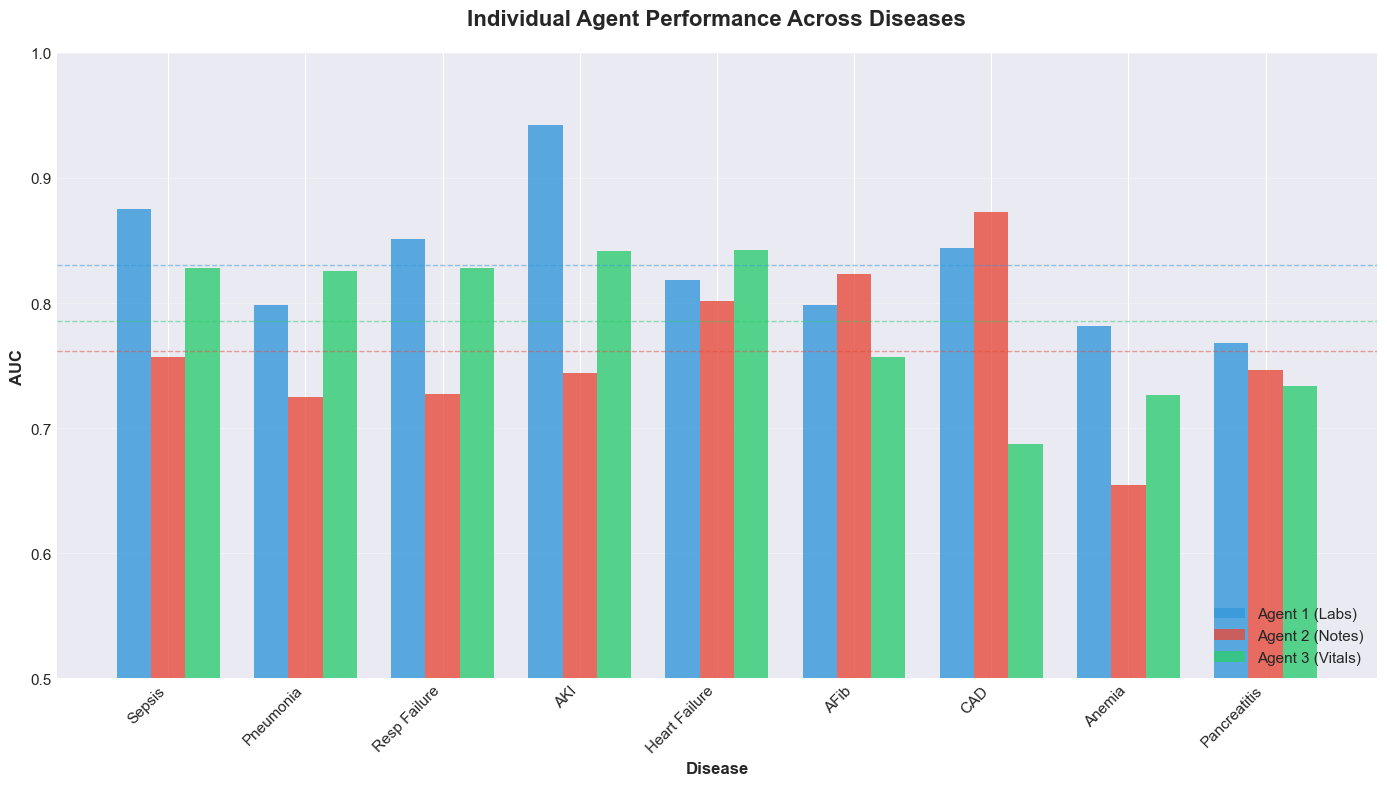

✅ Saved: ../results/agent_performance_comparison.png

📊 Average Performance:
  Agent 1 (Labs):   0.831
  Agent 2 (Notes):  0.762
  Agent 3 (Vitals): 0.786


In [5]:
print("\n📊 Creating Agent Performance Comparison Bar Chart...")

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(DISEASE_LIST))
width = 0.25

bars1 = ax.bar(x - width, results_df['Agent 1 (Labs)'], width, 
               label='Agent 1 (Labs)', alpha=0.8, color='#3498db')
bars2 = ax.bar(x, results_df['Agent 2 (Notes)'], width, 
               label='Agent 2 (Notes)', alpha=0.8, color='#e74c3c')
bars3 = ax.bar(x + width, results_df['Agent 3 (Vitals)'], width, 
               label='Agent 3 (Vitals)', alpha=0.8, color='#2ecc71')

# Customize
ax.set_xlabel('Disease', fontsize=12, fontweight='bold')
ax.set_ylabel('AUC', fontsize=12, fontweight='bold')
ax.set_title('Individual Agent Performance Across Diseases', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(disease_labels, rotation=45, ha='right')
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0.5, 1.0])

# Add average line
agent1_avg = results_df['Agent 1 (Labs)'].mean()
agent2_avg = results_df['Agent 2 (Notes)'].mean()
agent3_avg = results_df['Agent 3 (Vitals)'].mean()

ax.axhline(y=agent1_avg, color='#3498db', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(y=agent2_avg, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(y=agent3_avg, color='#2ecc71', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('../../results/agent_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: ../results/agent_performance_comparison.png")

print(f"\n📊 Average Performance:")
print(f"  Agent 1 (Labs):   {agent1_avg:.3f}")
print(f"  Agent 2 (Notes):  {agent2_avg:.3f}")
print(f"  Agent 3 (Vitals): {agent3_avg:.3f}")

In [9]:
print("\n" + "="*70)
print("🎯 FUSION COORDINATOR FEATURE IMPORTANCE")
print("="*70)
print("Analyzing which agents the fusion coordinator trusts for each disease\n")

fusion_importance = []

for disease in DISEASE_LIST:
    # Load fusion model - CORRECTED PATH
    model_path = f'../../models/fusion/fusion_{disease.lower()}.joblib'
    
    if not Path(model_path).exists():
        print(f"⚠️ Model not found: {model_path}")
        continue
    
    model = joblib.load(model_path)
    
    # Get feature importance (105 features in enhanced model)
    importance = model.feature_importances_
    
    # Original 33 features:
    # Features 0-8: Agent 1, 9-17: Agent 2, 18-26: Agent 3, 27-32: Meta
    # Then 72 additional engineered features (33-104)
    
    # Sum importance by agent (original features only for cleaner interpretation)
    agent1_importance = importance[0:9].sum()
    agent2_importance = importance[9:18].sum()
    agent3_importance = importance[18:27].sum()
    meta_importance = importance[27:33].sum()
    engineered_importance = importance[33:].sum() if len(importance) > 33 else 0
    
    # Normalize to percentages
    total = agent1_importance + agent2_importance + agent3_importance + meta_importance + engineered_importance
    
    fusion_importance.append({
        'Disease': disease,
        'Agent 1 (Labs) %': (agent1_importance / total) * 100,
        'Agent 2 (Notes) %': (agent2_importance / total) * 100,
        'Agent 3 (Vitals) %': (agent3_importance / total) * 100,
        'Meta Features %': (meta_importance / total) * 100,
        'Engineered %': (engineered_importance / total) * 100 if engineered_importance > 0 else 0
    })
    
    print(f"{disease}:")
    print(f"  Agent 1 (Labs):   {agent1_importance/total*100:5.1f}%")
    print(f"  Agent 2 (Notes):  {agent2_importance/total*100:5.1f}%")
    print(f"  Agent 3 (Vitals): {agent3_importance/total*100:5.1f}%")
    print(f"  Meta Features:    {meta_importance/total*100:5.1f}%")
    if engineered_importance > 0:
        print(f"  Engineered:       {engineered_importance/total*100:5.1f}%")
    print()

fusion_importance_df = pd.DataFrame(fusion_importance)

# Save
fusion_importance_df.to_csv('../../results/fusion_feature_importance.csv', index=False)
print("✅ Saved: ../results/fusion_feature_importance.csv")


🎯 FUSION COORDINATOR FEATURE IMPORTANCE
Analyzing which agents the fusion coordinator trusts for each disease

SEPSIS:
  Agent 1 (Labs):     8.9%
  Agent 2 (Notes):    7.4%
  Agent 3 (Vitals):   9.5%
  Meta Features:      4.9%
  Engineered:        69.4%

PNEUMONIA:
  Agent 1 (Labs):    10.0%
  Agent 2 (Notes):    7.3%
  Agent 3 (Vitals):  15.3%
  Meta Features:      2.5%
  Engineered:        64.8%

RESPIRATORY_FAILURE:
  Agent 1 (Labs):     9.3%
  Agent 2 (Notes):    6.9%
  Agent 3 (Vitals):  10.2%
  Meta Features:      4.4%
  Engineered:        69.2%

ACUTE_KIDNEY_INJURY:
  Agent 1 (Labs):    25.8%
  Agent 2 (Notes):    8.5%
  Agent 3 (Vitals):   7.7%
  Meta Features:      2.2%
  Engineered:        55.8%

HEART_FAILURE:
  Agent 1 (Labs):     6.3%
  Agent 2 (Notes):    4.7%
  Agent 3 (Vitals):  15.0%
  Meta Features:      2.3%
  Engineered:        71.8%

ATRIAL_FIBRILLATION:
  Agent 1 (Labs):     7.3%
  Agent 2 (Notes):    7.2%
  Agent 3 (Vitals):   7.5%
  Meta Features:      2.4%
  E


📊 Creating Fusion Trust Pattern Visualization...


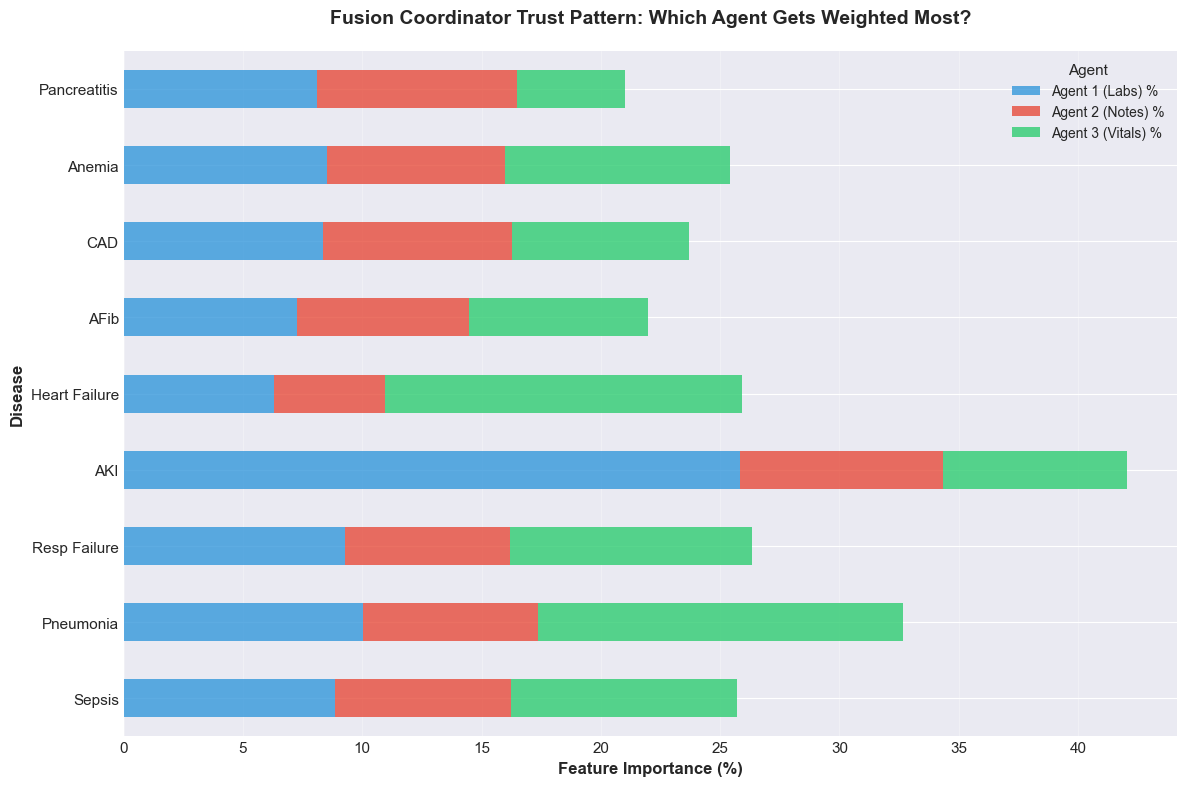

✅ Saved: ../results/fusion_trust_pattern.png


In [10]:
print("\n📊 Creating Fusion Trust Pattern Visualization...")

fig, ax = plt.subplots(figsize=(12, 8))

# Prepare data
plot_data = fusion_importance_df.set_index('Disease')[
    ['Agent 1 (Labs) %', 'Agent 2 (Notes) %', 'Agent 3 (Vitals) %']
]
plot_data.index = disease_labels

# Stacked bar chart
plot_data.plot(kind='barh', stacked=True, ax=ax, 
               color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8)

ax.set_xlabel('Feature Importance (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Disease', fontsize=12, fontweight='bold')
ax.set_title('Fusion Coordinator Trust Pattern: Which Agent Gets Weighted Most?',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(title='Agent', fontsize=10, title_fontsize=11)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../../results/fusion_trust_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: ../results/fusion_trust_pattern.png")

In [11]:
print("\n" + "="*70)
print("📊 SUMMARY STATISTICS")
print("="*70)

print("\n1. AGENT DOMINANCE:")
agent_wins = results_df['Best Agent'].value_counts()
for agent, count in agent_wins.items():
    print(f"   {agent}: {count} diseases ({count/9*100:.1f}%)")

print("\n2. AVERAGE PERFORMANCE GAP:")
avg_gap = results_df['Gap'].mean()
print(f"   Average performance gap between best and 2nd best: {avg_gap:.3f} AUC")
print(f"   This shows {'strong' if avg_gap > 0.05 else 'moderate'} specialization")

print("\n3. CONSISTENCY:")
agent1_std = results_df['Agent 1 (Labs)'].std()
agent2_std = results_df['Agent 2 (Notes)'].std()
agent3_std = results_df['Agent 3 (Vitals)'].std()
print(f"   Agent 1 performance variability (std): {agent1_std:.3f}")
print(f"   Agent 2 performance variability (std): {agent2_std:.3f}")
print(f"   Agent 3 performance variability (std): {agent3_std:.3f}")
print(f"   → Most consistent: Agent {1 if agent1_std < min(agent2_std, agent3_std) else 2 if agent2_std < agent3_std else 3}")

print("\n4. FUSION ALIGNMENT:")
print("   Does fusion trust the right agents?")
for _, row in fusion_importance_df.iterrows():
    disease = row['Disease']
    best_agent = results_df[results_df['Disease'] == disease]['Best Agent'].values[0]
    
    if 'Agent 1' in best_agent:
        fusion_trust = row['Agent 1 (Labs) %']
    elif 'Agent 2' in best_agent:
        fusion_trust = row['Agent 2 (Notes) %']
    else:
        fusion_trust = row['Agent 3 (Vitals) %']
    
    aligned = "✅" if fusion_trust > 35 else "⚠️"
    print(f"   {disease:30s} → {aligned} Fusion trusts {best_agent} at {fusion_trust:.1f}%")


📊 SUMMARY STATISTICS

1. AGENT DOMINANCE:
   Agent 1: 5 diseases (55.6%)
   Agent 3: 2 diseases (22.2%)
   Agent 2: 2 diseases (22.2%)

2. AVERAGE PERFORMANCE GAP:
   Average performance gap between best and 2nd best: 0.039 AUC
   This shows moderate specialization

3. CONSISTENCY:
   Agent 1 performance variability (std): 0.054
   Agent 2 performance variability (std): 0.064
   Agent 3 performance variability (std): 0.059
   → Most consistent: Agent 1

4. FUSION ALIGNMENT:
   Does fusion trust the right agents?
   SEPSIS                         → ⚠️ Fusion trusts Agent 1 at 8.9%
   PNEUMONIA                      → ⚠️ Fusion trusts Agent 3 at 15.3%
   RESPIRATORY_FAILURE            → ⚠️ Fusion trusts Agent 1 at 9.3%
   ACUTE_KIDNEY_INJURY            → ⚠️ Fusion trusts Agent 1 at 25.8%
   HEART_FAILURE                  → ⚠️ Fusion trusts Agent 3 at 15.0%
   ATRIAL_FIBRILLATION            → ⚠️ Fusion trusts Agent 2 at 7.2%
   CORONARY_ARTERY_DISEASE        → ⚠️ Fusion trusts Agent 2 at 